In [20]:
import requests
import pandas as pd


url = "https://api.binance.com/api/v3/klines"
params = {"symbol": "BTCUSDT" , "interval": "1h", "limit": 1000}
raw = requests.get(url, params=params).json()

df = pd.DataFrame([row[:6] for row in raw], columns=['Time','Open','High','Low','Close','Volume'])
df['Time'] = pd.to_datetime(df['Time'],unit='ms')
df['Close'] = df['Close'].astype(float)
df.head(-5)

,Time,Open,High,Low,Close,Volume
0,2026-03-21 23:00:00,70277.21000000,70293.82000000,68571.42000000,68918.12,2509.60568000
1,2026-03-22 00:00:00,68918.12000000,69155.86000000,68228.50000000,68954.71,2161.16442000
2,2026-03-22 01:00:00,68954.70000000,69100.00000000,68762.31000000,68962.40,809.55651000
3,2026-03-22 02:00:00,68962.40000000,69411.10000000,68951.21000000,69278.12,506.62838000
4,2026-03-22 03:00:00,69278.12000000,69588.79000000,69123.13000000,69339.99,671.14040000
...,...,...,...,...,...,...
990,2026-05-02 05:00:00,78175.50000000,78235.25000000,78040.00000000,78174.00,526.60294000
991,2026-05-02 06:00:00,78174.00000000,78363.21000000,78148.24000000,78327.80,366.56450000
992,2026-05-02 07:00:00,78327.80000000,78342.18000000,78207.20000000,78220.00,170.02066000
993,2026-05-02 08:00:00,78220.00000000,78356.51000000,78165.30000000,78315.37,204.83037000


In [28]:
import numpy as np
df['ma10'] = df['Close'].rolling(window=10).mean()
df['ma30'] = df['Close'].rolling(window=30).mean()
df['signal'] = np.where( df['ma10'] < df['ma30'], 1, 0 )
arr=df['signal']
df['signal'] = np.where( df['ma30'] < df['ma10'] , -1 , arr)
df['signal'].value_counts()

signal
-1    540
 1    431
 0     29
Name: count, dtype: int64

In [31]:
df['pct_return'] = df['Close'].pct_change()*df['signal'].shift(1)
df['cumulative'] = (1+df['pct_return']).cumprod()
df['buynhold'] = df['Close']/df['Close'][0]
df['cumulative'].value_counts()

cumulative
1.000000    29
1.005237     1
0.990271     1
0.996968     1
0.998443     1
            ..
1.183567     1
1.185173     1
1.184139     1
1.181780     1
1.182643     1
Name: count, Length: 971, dtype: int64

TypeError: index type not supported

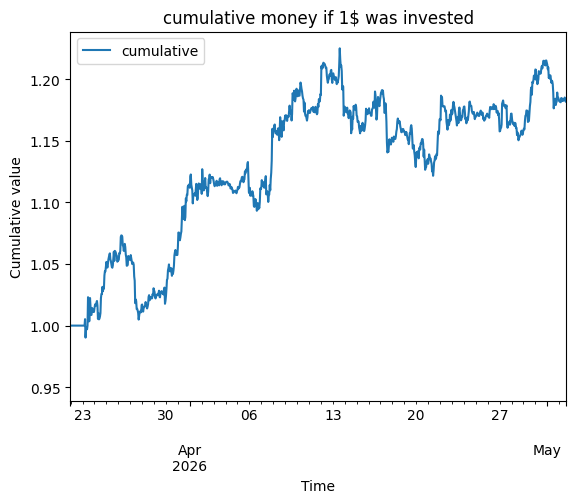

In [ ]:
import matplotlib.pyplot as plt
df.plot(x='Time',y='cumulative', kind ='line', title= 'cumulative money if 1$ was invested', ylabel = 'Cumulative value')

df.plot(y='buynhold', kind = 'line', color = 'red', label = 'Buy&Hold')
plt.xlabel('Time')
plt.savefig('results.png')
plt.show()